In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df=pd.read_csv(r"C:\Users\gourav verma\OneDrive\Desktop\python for ML\cleaned_airline_weekendS.csv")

In [80]:
#functions
def sum_dur_hrs(li: list) -> object:
    d, h, m, s = 0, 0, 0, 0
    for i in li:
        t = i.split(":")
        h += int(t[0])
        m += int(t[1])
        s += int(t[2])

        if s >= 60:
            m += s // 60
            s = s % 60

        if m >= 60:
            h += m // 60
            m = m % 60

        if h >= 24:
            d += h // 24
            h = h % 24

    return f"{d} days,{h:02d}:{m:02d}:{s:02d}"

def rng_dm(n):
    a = n.split(":")
    res = []
    h, m = 0, 0

    while h <= int(a[0]):
        while (h < int(a[0]) and m <= 59) or (h == int(a[0]) and m <= int(a[1])):
            res.append(f"{h:02d}:{m:02d}:00")
            m += 10
        h += 1
        m = 0

    return res

def stp_dm(r):
    a = r.split(":")
    h = int(a[0])
    m = int(a[1])
    return f"{h:02d}:{m+9:02d}:59"

def months(i):
    month = {
        1: "January",
        2: "February",
        3: "March",
        4: "April",
        5: "May",
        6: "June",
        7: "July",
        8: "August",
        9: "September",
        10: "October",
        11: "November",
        12: "December"
    }
    if i in month:
        return month[i]




In [81]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")


In [82]:
df

,Flight_Number,Airline,Aircraft_Type,Origin,Destination,Date,Distance_km,Duration_hours,Ticket_Price,Fuel_Cost,Weather_Condition,Delay_minutes,Passenger_Count
0,8498,SpiceJet,ATR72,CCU,MAA,2023-06-12,1384.0,03:05:42,2963.516704,3828.490167,Cloudy,000:000,62
1,5263,IndiGo,A320,AMD,PNQ,2023-09-21,519.0,01:07:60,2912.486246,1790.502002,Cloudy,027:055,119
2,1877,GoAir,B737,CCU,DEL,2023-11-30,1423.0,02:06:45,2177.869901,5122.704201,Cloudy,026:020,122
3,1598,GoAir,B737,AMD,HYD,2023-06-30,907.0,01:30:56,2204.381503,3289.369504,Cloudy,013:046,143
4,2722,GoAir,ATR72,HYD,PNQ,2023-10-24,529.0,01:43:03,2321.112931,1543.099700,Clear,018:055,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2098,GoAir,A321,CCU,AMD,2023-12-06,1753.0,02:31:52,2995.180173,6435.115093,Clear,007:044,195
99996,1978,GoAir,A321,AMD,PNQ,2023-07-21,519.0,01:08:14,2971.397586,2030.405612,Clear,003:034,158
99997,7474,Air India,A320,DEL,DEL,2023-08-29,0.0,00:30:00,3380.840213,500.000000,Clear,000:000,93
99998,2248,IndiGo,B777,MAA,PNQ,2023-07-17,933.0,01:25:30,3542.425616,3908.780885,Rainy,027:058,243


In [83]:
# graphs and charts basis on airlines
acd={i:[df[(df["Airline"]==i)&(df["Distance_km"]!=0.0)]["Flight_Number"].count()
        ,df[(df["Airline"]==i)&(df["Distance_km"]==0.0)]["Flight_Number"].count()]
        for i in df["Airline"].unique().tolist()}
Airline_dept_cancel=pd.DataFrame.from_dict(acd,orient="index",columns=["Departed","Cancelled"])
acd

{'SpiceJet': [np.int64(16874), np.int64(3033)],
 'IndiGo': [np.int64(16920), np.int64(3042)],
 'GoAir': [np.int64(16981), np.int64(2993)],
 'Air India': [np.int64(17092), np.int64(3132)],
 'Vistara': [np.int64(16865), np.int64(3068)]}

In [84]:
air=Airline_dept_cancel.index.tolist()
x=np.arange(len(air))
x

array([0, 1, 2, 3, 4])

In [85]:
Airline_dept_cancel

,Departed,Cancelled
SpiceJet,16874,3033
IndiGo,16920,3042
GoAir,16981,2993
Air India,17092,3132
Vistara,16865,3068


In [86]:
# Graphs and Charts on the basis of Airlines

acd = {
    i: [
        df[(df["Airline"] == i) & (df["Distance_km"] != 0.0)]["Flight_Number"].count(),
        df[(df["Airline"] == i) & (df["Distance_km"] == 0.0)]["Flight_Number"].count()
    ]
    for i in df["Airline"].unique().tolist()
}

Airline_dept_cancel = pd.DataFrame.from_dict(
    acd,
    orient="index",
    columns=["Departed", "Cancelled"]
)

Airline_ontime_delayed = pd.DataFrame.from_dict(
    {
        i: [
            df[(df["Airline"] == i) &
               (df["Delay_minutes"] <= "00:01:00")]["Flight_Number"].count(),

            df[(df["Airline"] == i) &
               (df["Delay_minutes"] > "00:01:00")]["Flight_Number"].count()
        ]
        for i in df["Airline"].unique().tolist()
    },
    orient="index",
    columns=["On-Time", "Delayed"]
)
ttp = (df[df["Distance_km"] != 0].groupby("Airline")["Ticket_Price"].sum().to_dict())
cttp=df[df["Distance_km"]==0.0].groupby("Airline")["Ticket_Price"].sum().to_dict()
tfc=df.groupby("Airline")["Fuel_Cost"].sum().to_dict()
Airline_Profit=pd.DataFrame.from_dict({i:round(ttp[i]+(0.1*cttp[i])-tfc[i],2)for i in ttp},orient="index",columns=["Total_Profit"])
Airline_Avg_Passengers = pd.DataFrame.from_dict({i: [df[(df["Airline"] == i) &(df["Distance_km"] == 0.0)]["Passenger_Count"].mean(),
df[(df["Airline"] == i) & (df["Distance_km"] != 0.0)]["Passenger_Count"].mean() ]for i in df["Airline"].unique()},orient="index",
columns=["Avg_Canc_passengers", "Avg_Dept_passengers"])


Airline_toff_count = pd.DataFrame.from_dict(
    {
        i: {
            p: list(j.values()).count(p)
            for p in set(j.values())
        }
        for i, j in {
            i: df[
                (df["Distance_km"] != 0.0) &
                (df["Airline"] == i)
            ]["Flight_Number"].value_counts().to_dict()
            for i in df["Airline"].unique().tolist()
        }.items()
    },
    orient="index"
).fillna(0).astype("int")


Airline_coff_count = pd.DataFrame.from_dict(
    {
        i: {
            p: list(j.values()).count(p)
            for p in set(j.values())
        }
        for i, j in {
            i: df[
                (df["Distance_km"] == 0.0) &  
                (df["Airline"] == i)
            ]["Flight_Number"].value_counts().to_dict()
            for i in df["Airline"].unique().tolist()
        }.items()
    },
    orient="index"
).fillna(0).astype("int")






In [87]:
Airline_Avg_Passengers

,Avg_Canc_passengers,Avg_Dept_passengers
SpiceJet,107.575668,147.332109
IndiGo,107.421433,148.486466
GoAir,110.390578,148.842648
Air India,108.925926,148.261584
Vistara,107.010104,149.467951


In [88]:
Airline_Avg_Passengers

,Avg_Canc_passengers,Avg_Dept_passengers
SpiceJet,107.575668,147.332109
IndiGo,107.421433,148.486466
GoAir,110.390578,148.842648
Air India,108.925926,148.261584
Vistara,107.010104,149.467951


In [89]:
Airline_coff_count

,1,2,3,4,6,5
SpiceJet,2189,351,42,4,0,0
IndiGo,2164,360,46,5,0,0
GoAir,2139,348,44,5,1,0
Air India,2207,386,44,4,0,1
Vistara,2168,371,42,8,0,0


In [90]:
Airline_toff_count

,1,2,3,4,5,6,7,8,9,10
SpiceJet,2566,2456,1484,734,266,77,19,8,1,1
IndiGo,2543,2494,1483,696,275,99,24,0,1,1
GoAir,2525,2457,1555,724,249,88,24,5,0,0
Air India,2549,2435,1573,706,262,80,37,9,1,0
Vistara,2620,2415,1509,665,290,90,27,5,1,0


In [91]:
import pandas as pd
import numpy as np



def time_to_hours(t):
    if pd.isna(t):
        return 0.0
    if isinstance(t, (int, float)):
        return float(t)
    h, m, s = map(int, t.split(":"))
    return h + m/60 + s/3600

df["Duration_hours_num"] = df["Duration_hours"].apply(time_to_hours)


Cancelled_airtype = pd.DataFrame.from_dict(
    {
        i: df[
            (df["Distance_km"] == 0.0) &
            (df["Airline"] == i)
        ].groupby("Aircraft_Type")["Flight_Number"].count().to_dict()
        for i in df["Airline"].unique()
    },
    orient="index"
).fillna(0).astype(int)



Departed_airtype = pd.DataFrame.from_dict(
    {
        i: df[
            (df["Distance_km"] != 0.0) &
            (df["Airline"] == i)
        ].groupby("Aircraft_Type")["Flight_Number"].count().to_dict()
        for i in df["Airline"].unique()
    },
    orient="index"
).fillna(0).astype(int)



Total_flight_time=pd.DataFrame.from_dict({i:{k:sum_dur_hrs(df[(df["Airline"]==i) & 
                                            (df["Aircraft_Type"]==k) & 
                                            (df["Distance_km"]!=0.0)]["Duration_hours"].tolist()) for k in j 
                                            } for i,j in df.groupby("Airline")["Aircraft_Type"].unique().to_dict().items()}
                                            ,orient="index").fillna("not_calculated").astype("object")

origin_aircraft_count = (
    df.groupby(["Airline", "Aircraft_Type", "Origin"], as_index=False)
      .agg(Origin_Flight_Count=("Flight_Number", "count"))
)



dest_aircraft_count = (
    df.groupby(["Airline", "Aircraft_Type", "Destination"], as_index=False)
      .agg(Destination_Flight_Count=("Flight_Number", "count"))
)

ttp = {
    i: df[
        (df["Airline"] == i) &
        (df["Distance_km"] != 0.0)
    ].groupby("Aircraft_Type")["Ticket_Price"].sum().to_dict()
    for i in df["Airline"].unique()
}



cttp = {
    i: df[
        (df["Airline"] == i) &
        (df["Distance_km"] == 0.0)
    ].groupby("Aircraft_Type")["Ticket_Price"].sum().to_dict()
    for i in df["Airline"].unique()
}



tcf = {
    i: df[df["Airline"] == i]
        .groupby("Aircraft_Type")["Fuel_Cost"]
        .sum()
        .to_dict()
    for i in df["Airline"].unique()
}



airtype_profit = pd.DataFrame.from_dict(
    {
        i: {
            j: round(
                ttp[i].get(j, 0) +
                (0.1 * cttp[i].get(j, 0)) -
                tcf[i].get(j, 0),
                2
            )
            for j in set(ttp[i]) | set(cttp[i]) | set(tcf[i])
        }
        for i in df["Airline"].unique()
    },
    orient="index"
).fillna(0)


In [92]:
df

,Flight_Number,Airline,Aircraft_Type,Origin,Destination,Date,Distance_km,Duration_hours,Ticket_Price,Fuel_Cost,Weather_Condition,Delay_minutes,Passenger_Count,Duration_hours_num
0,8498,SpiceJet,ATR72,CCU,MAA,2023-06-12,1384.0,03:05:42,2963.516704,3828.490167,Cloudy,000:000,62,3.095000
1,5263,IndiGo,A320,AMD,PNQ,2023-09-21,519.0,01:07:60,2912.486246,1790.502002,Cloudy,027:055,119,1.133333
2,1877,GoAir,B737,CCU,DEL,2023-11-30,1423.0,02:06:45,2177.869901,5122.704201,Cloudy,026:020,122,2.112500
3,1598,GoAir,B737,AMD,HYD,2023-06-30,907.0,01:30:56,2204.381503,3289.369504,Cloudy,013:046,143,1.515556
4,2722,GoAir,ATR72,HYD,PNQ,2023-10-24,529.0,01:43:03,2321.112931,1543.099700,Clear,018:055,40,1.717500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2098,GoAir,A321,CCU,AMD,2023-12-06,1753.0,02:31:52,2995.180173,6435.115093,Clear,007:044,195,2.531111
99996,1978,GoAir,A321,AMD,PNQ,2023-07-21,519.0,01:08:14,2971.397586,2030.405612,Clear,003:034,158,1.137222
99997,7474,Air India,A320,DEL,DEL,2023-08-29,0.0,00:30:00,3380.840213,500.000000,Clear,000:000,93,0.500000
99998,2248,IndiGo,B777,MAA,PNQ,2023-07-17,933.0,01:25:30,3542.425616,3908.780885,Rainy,027:058,243,1.425000


In [93]:
DFC = (
    df[df["Distance_km"] != 0.0]
    .assign(
        month=df["Date"].dt.month,
        Days=df["Date"].dt.day
    )
    .groupby(["month", "Days"], as_index=False)
    .agg(flight_count=("Flight_Number", "count"))
)

Daily_flight_count = (
    DFC.pivot_table(
        index="month",
        columns="Days",
        values="flight_count",
        fill_value=0
    )
    .astype(int)
    .reset_index()
)

Daily_flight_count["month"] = Daily_flight_count["month"].apply(lambda x: months(x))
DFC

,month,Days,flight_count
0,1,1,232
1,1,2,215
2,1,3,240
3,1,4,221
4,1,5,243
...,...,...,...
360,12,27,247
361,12,28,221
362,12,29,222
363,12,30,225


In [94]:
ADPC = (
    df[df["Distance_km"] != 0.0]
    .assign(
        Month=df["Date"].dt.month,
        Days=df["Date"].dt.day
    )
    .groupby(["Airline", "Month", "Days"], as_index=False)
    .agg(passenger_count=("Passenger_Count", "sum"))
)

Airline_Daily_passenger_count = (
    ADPC.pivot_table(
        index=["Airline", "Month"],
        columns="Days",
        values="passenger_count",
        fill_value=0
    )
    .astype(int)
    .reset_index()
)

Airline_Daily_passenger_count["Month"] = (
    Airline_Daily_passenger_count["Month"].apply(lambda x: months(x))
)
ADPC


,Airline,Month,Days,passenger_count
0,Air India,1,1,6480
1,Air India,1,2,7366
2,Air India,1,3,7061
3,Air India,1,4,6375
4,Air India,1,5,5850
...,...,...,...,...
1820,Vistara,12,27,7595
1821,Vistara,12,28,5774
1822,Vistara,12,29,7690
1823,Vistara,12,30,5957


In [95]:
air=Airline_dept_cancel

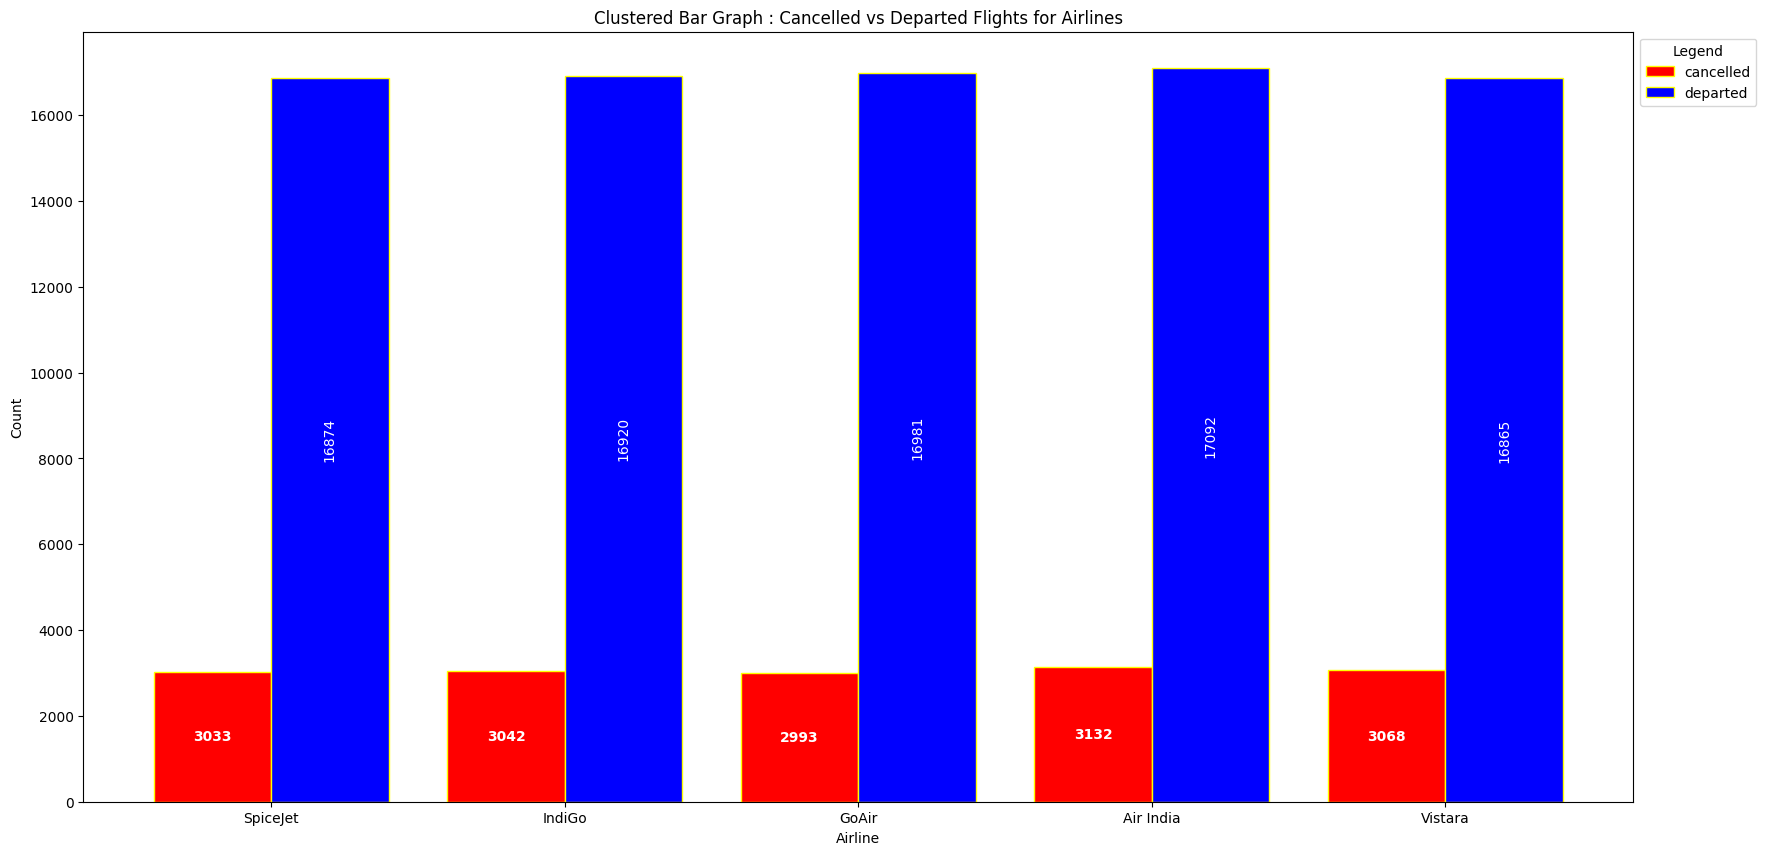

In [96]:
air=Airline_dept_cancel.index
x=np.arange(len(air))
barwidth=0.8/2
plt.figure(figsize=(20,10))
for i,airline in enumerate(air):
    b1=plt.bar(x[i]-barwidth/2,Airline_dept_cancel.loc[airline,"Cancelled"],barwidth,color="red",label="cancelled" if i==0 else None,edgecolor="yellow",linewidth=1)
    b2=plt.bar(x[i]+barwidth/2,Airline_dept_cancel.loc[airline,"Departed"],barwidth,color="blue",label="departed" if i==0 else None,edgecolor="yellow",linewidth=1)
    plt.bar_label(b1,label_type="center",color="white",fontweight="bold")
    plt.bar_label(b2,label_type="center",color="white",rotation=90)

plt.xticks(x,air)
plt.xlabel("Airline")
plt.ylabel("Count")
plt.title("Clustered Bar Graph : Cancelled vs Departed Flights for Airlines")
plt.legend(title="Legend",bbox_to_anchor=(1,1))
plt.show()

In [97]:
 Airline_ontime_delayed

,On-Time,Delayed
SpiceJet,6976,12931
IndiGo,6939,13023
GoAir,6938,13036
Air India,7065,13159
Vistara,6882,13051


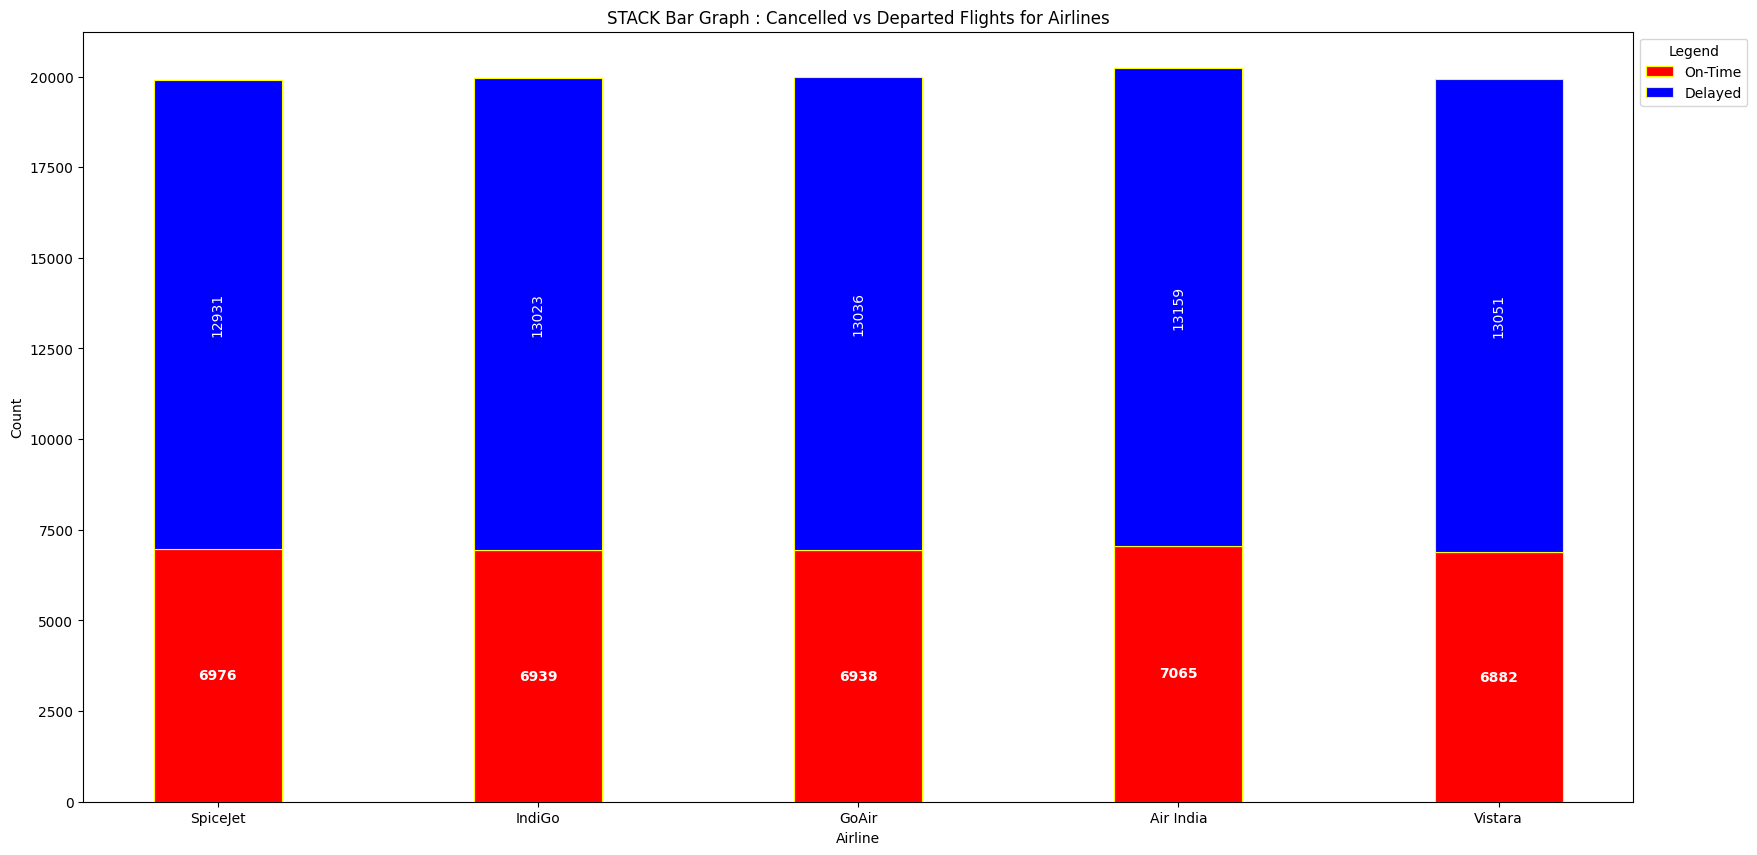

In [98]:
air=Airline_ontime_delayed.index
x=np.arange(len(air))
barwidth=0.8/2
plt.figure(figsize=(20,10))
for i,airline in enumerate(air):
    b1=plt.bar(x[i],Airline_ontime_delayed.loc[airline,"On-Time"],barwidth,color="red",label="On-Time" if i==0 else None,edgecolor="yellow",linewidth=0.8)
    b2=plt.bar(x[i],Airline_ontime_delayed.loc[airline,"Delayed"],width=barwidth,bottom=Airline_ontime_delayed.loc[airline,"On-Time"],color="blue",label="Delayed" if i==0 else None,edgecolor="yellow",linewidth=0.8)
    plt.bar_label(b1,label_type="center",color="white",fontweight="bold")
    plt.bar_label(b2,label_type="center",color="white",rotation=90)

plt.xticks(x,air)
plt.xlabel("Airline")
plt.ylabel("Count")
plt.title("STACK Bar Graph : Cancelled vs Departed Flights for Airlines")
plt.legend(title="Legend",bbox_to_anchor=(1,1))
plt.show()

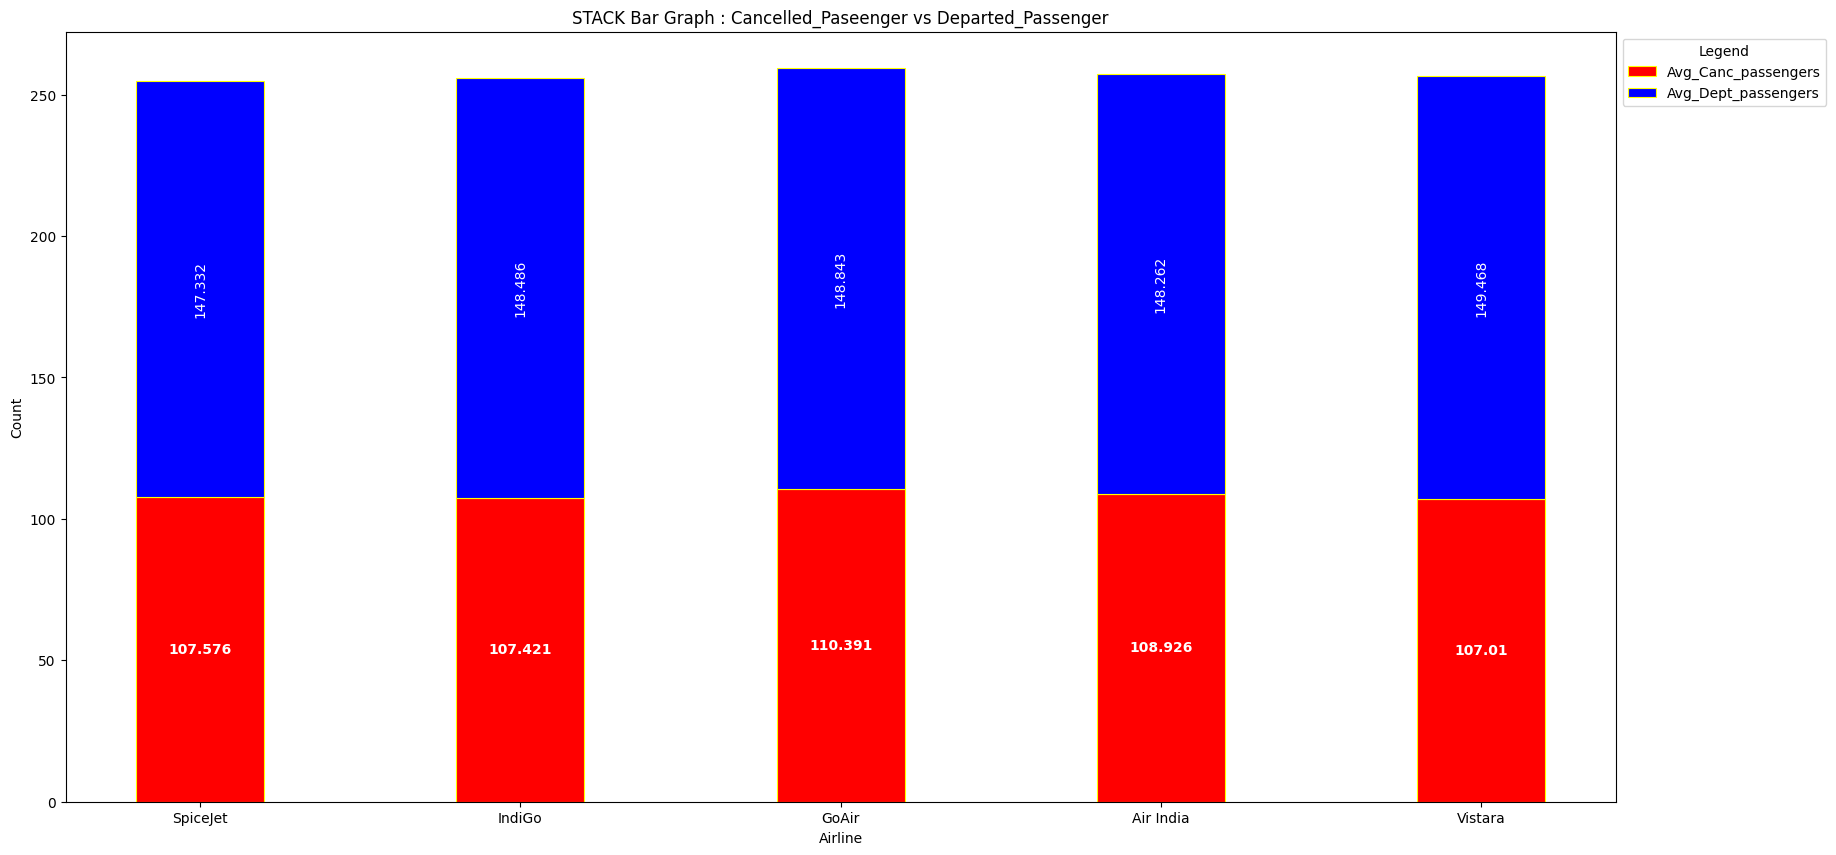

In [99]:
air=Airline_Avg_Passengers.index
x=np.arange(len(air))
barwidth=0.8/2
plt.figure(figsize=(20,10))
for i,airline in enumerate(air):
    b1=plt.bar(x[i],Airline_Avg_Passengers.loc[airline,"Avg_Canc_passengers"],barwidth,color="red",label="Avg_Canc_passengers" if i==0 else None,edgecolor="yellow",linewidth=0.8)
    b2=plt.bar(x[i],Airline_Avg_Passengers.loc[airline,"Avg_Dept_passengers"],width=barwidth,bottom=Airline_Avg_Passengers.loc[airline,"Avg_Canc_passengers"],color="blue",label="Avg_Dept_passengers" if i==0 else None,edgecolor="yellow",linewidth=0.8)
    plt.bar_label(b1,label_type="center",color="white",fontweight="bold")
    plt.bar_label(b2,label_type="center",color="white",rotation=90)

plt.xticks(x,air)
plt.xlabel("Airline")
plt.ylabel("Count")
plt.title("STACK Bar Graph : Cancelled_Paseenger vs Departed_Passenger")
plt.legend(title="Legend",bbox_to_anchor=(1,1))
plt.show()

In [100]:
Airline_Avg_Passengers

,Avg_Canc_passengers,Avg_Dept_passengers
SpiceJet,107.575668,147.332109
IndiGo,107.421433,148.486466
GoAir,110.390578,148.842648
Air India,108.925926,148.261584
Vistara,107.010104,149.467951


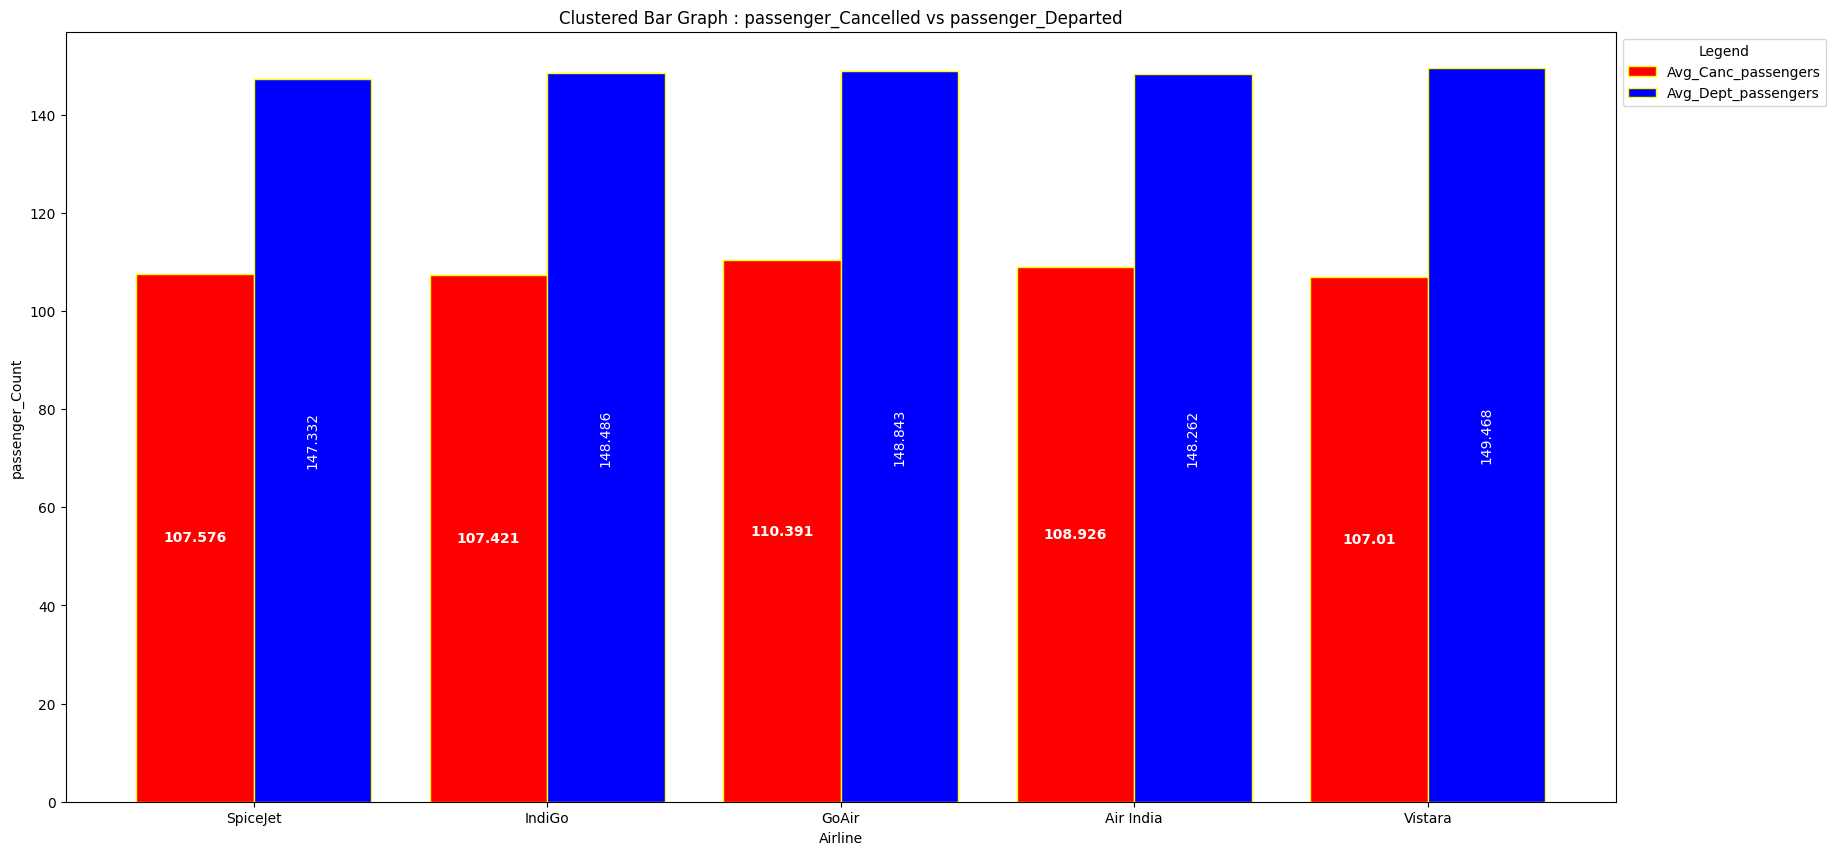

In [101]:
air=Airline_Avg_Passengers.index
x=np.arange(len(air))
barwidth=0.8/2
plt.figure(figsize=(20,10))
for i,airline in enumerate(air):
    b1=plt.bar(x[i]-barwidth/2,Airline_Avg_Passengers.loc[airline,"Avg_Canc_passengers"],barwidth,color="red",label="Avg_Canc_passengers" if i==0 else None,edgecolor="yellow",linewidth=1)
    b2=plt.bar(x[i]+barwidth/2,Airline_Avg_Passengers.loc[airline,"Avg_Dept_passengers"],barwidth,color="blue",label="Avg_Dept_passengers" if i==0 else None,edgecolor="yellow",linewidth=1)
    plt.bar_label(b1,label_type="center",color="white",fontweight="bold")
    plt.bar_label(b2,label_type="center",color="white",rotation=90)

plt.xticks(x,air)
plt.xlabel("Airline")
plt.ylabel("passenger_Count")
plt.title("Clustered Bar Graph : passenger_Cancelled vs passenger_Departed")
plt.legend(title="Legend",bbox_to_anchor=(1,1))
plt.show()

In [102]:
Airline_dept_cancel

,Departed,Cancelled
SpiceJet,16874,3033
IndiGo,16920,3042
GoAir,16981,2993
Air India,17092,3132
Vistara,16865,3068


In [103]:
Airline_coff_count

,1,2,3,4,6,5
SpiceJet,2189,351,42,4,0,0
IndiGo,2164,360,46,5,0,0
GoAir,2139,348,44,5,1,0
Air India,2207,386,44,4,0,1
Vistara,2168,371,42,8,0,0


In [104]:
Airline_toff_count

,1,2,3,4,5,6,7,8,9,10
SpiceJet,2566,2456,1484,734,266,77,19,8,1,1
IndiGo,2543,2494,1483,696,275,99,24,0,1,1
GoAir,2525,2457,1555,724,249,88,24,5,0,0
Air India,2549,2435,1573,706,262,80,37,9,1,0
Vistara,2620,2415,1509,665,290,90,27,5,1,0


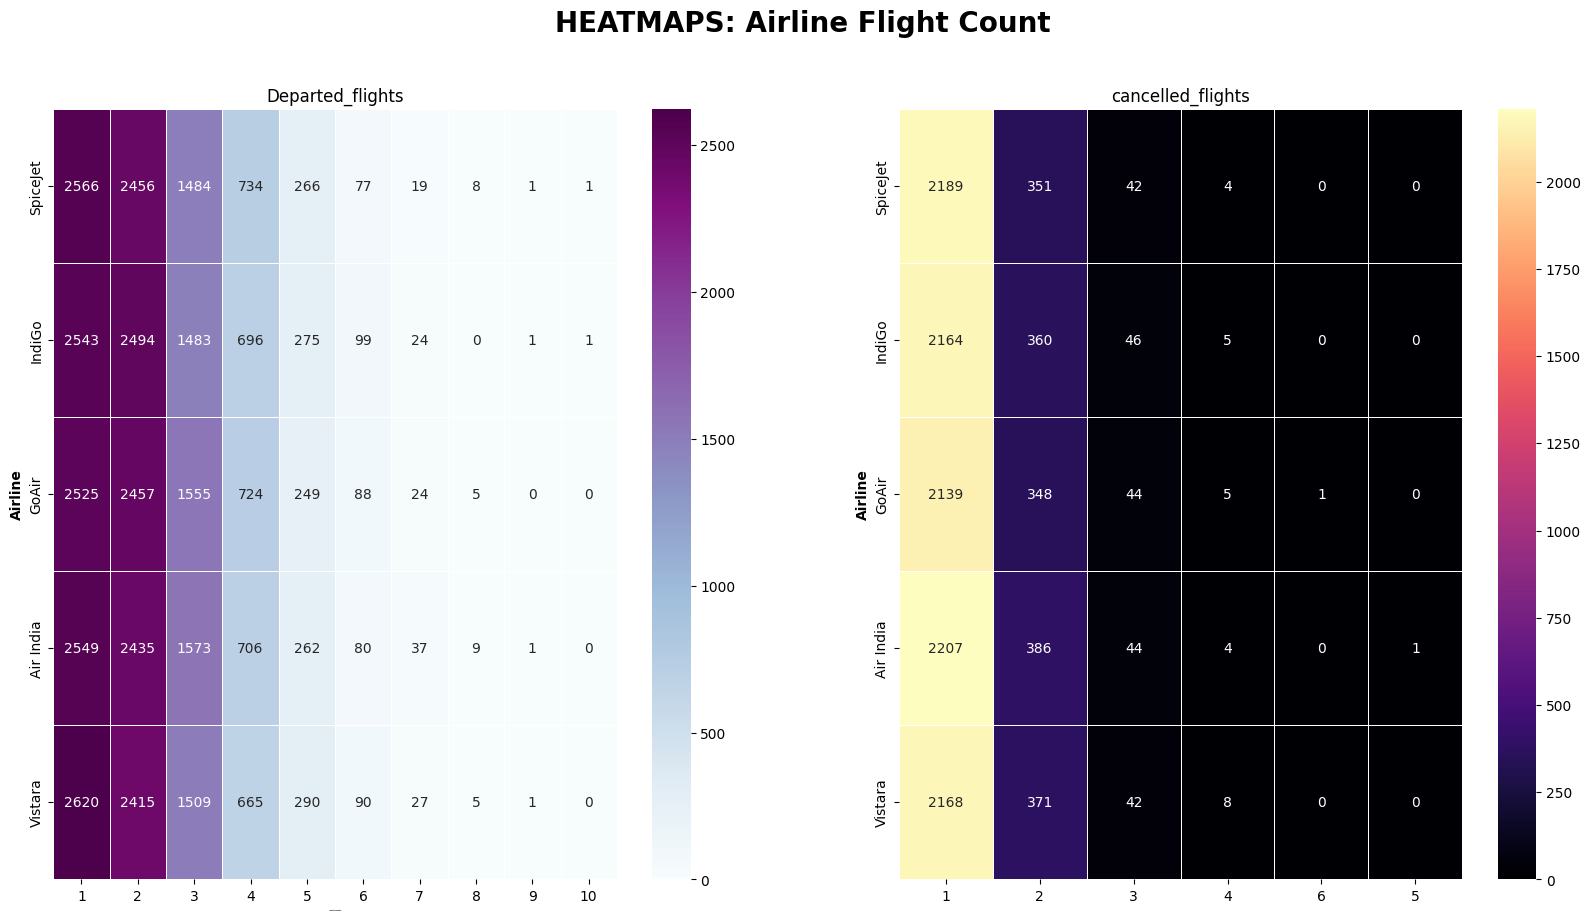

In [105]:
import seaborn as sns
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(20,10))
sns.heatmap(Airline_toff_count,annot=True,fmt="d",ax=ax1,cmap="BuPu",linewidths=0.5)
sns.heatmap(Airline_coff_count,annot=True,fmt="d",ax=ax2,cmap="magma",linewidths=0.5)
ax1.set_title("Departed_flights")
ax2.set_title("cancelled_flights")
ax1.set_ylabel("Airline",fontsize=10,fontweight="bold")
ax2.set_ylabel("Airline",fontsize=10,fontweight="bold")
ax1.set_xlabel("count of flights",fontsize=10,fontweight="bold")
ax1.set_xlabel("count of flights",fontsize=0,fontweight="bold")
plt.suptitle("HEATMAPS: Airline Flight Count",fontsize=20,fontweight="bold")
plt.show()


In [106]:
from matplotlib.patches import Patch

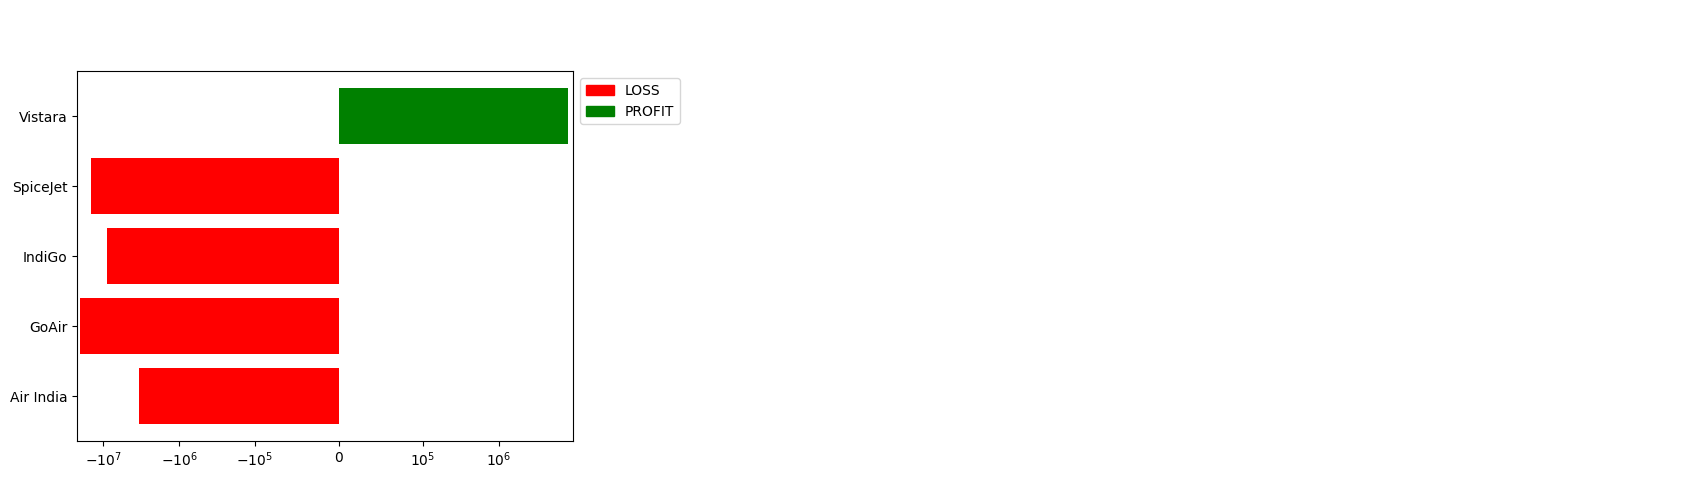

In [107]:
b1=plt.barh(Airline_Profit.index,Airline_Profit["Total_Profit"],color=["red" if i<0 else "green" for i in Airline_Profit["Total_Profit"]])
plt.bar_label(b2,label_type="center",fmt="%.2f",color="white",fontweight="bold")
plt.xscale("symlog",linthresh=1e5)
plt.legend(handles=[Patch(color="red",label="LOSS"),Patch(color="green",label="PROFIT")],bbox_to_anchor=(1,1))
plt.show()

In [108]:
Cancelled_airtype


,A320,A321,ATR72,B737,B777
SpiceJet,584,593,650,608,598
IndiGo,618,619,624,600,581
GoAir,594,619,576,597,607
Air India,619,641,660,573,639
Vistara,600,575,666,643,584


In [109]:
Departed_airtype

,A320,A321,ATR72,B737,B777
SpiceJet,3415,3390,3420,3373,3276
IndiGo,3359,3368,3478,3269,3446
GoAir,3533,3296,3328,3405,3419
Air India,3415,3406,3394,3489,3388
Vistara,3286,3392,3348,3368,3471


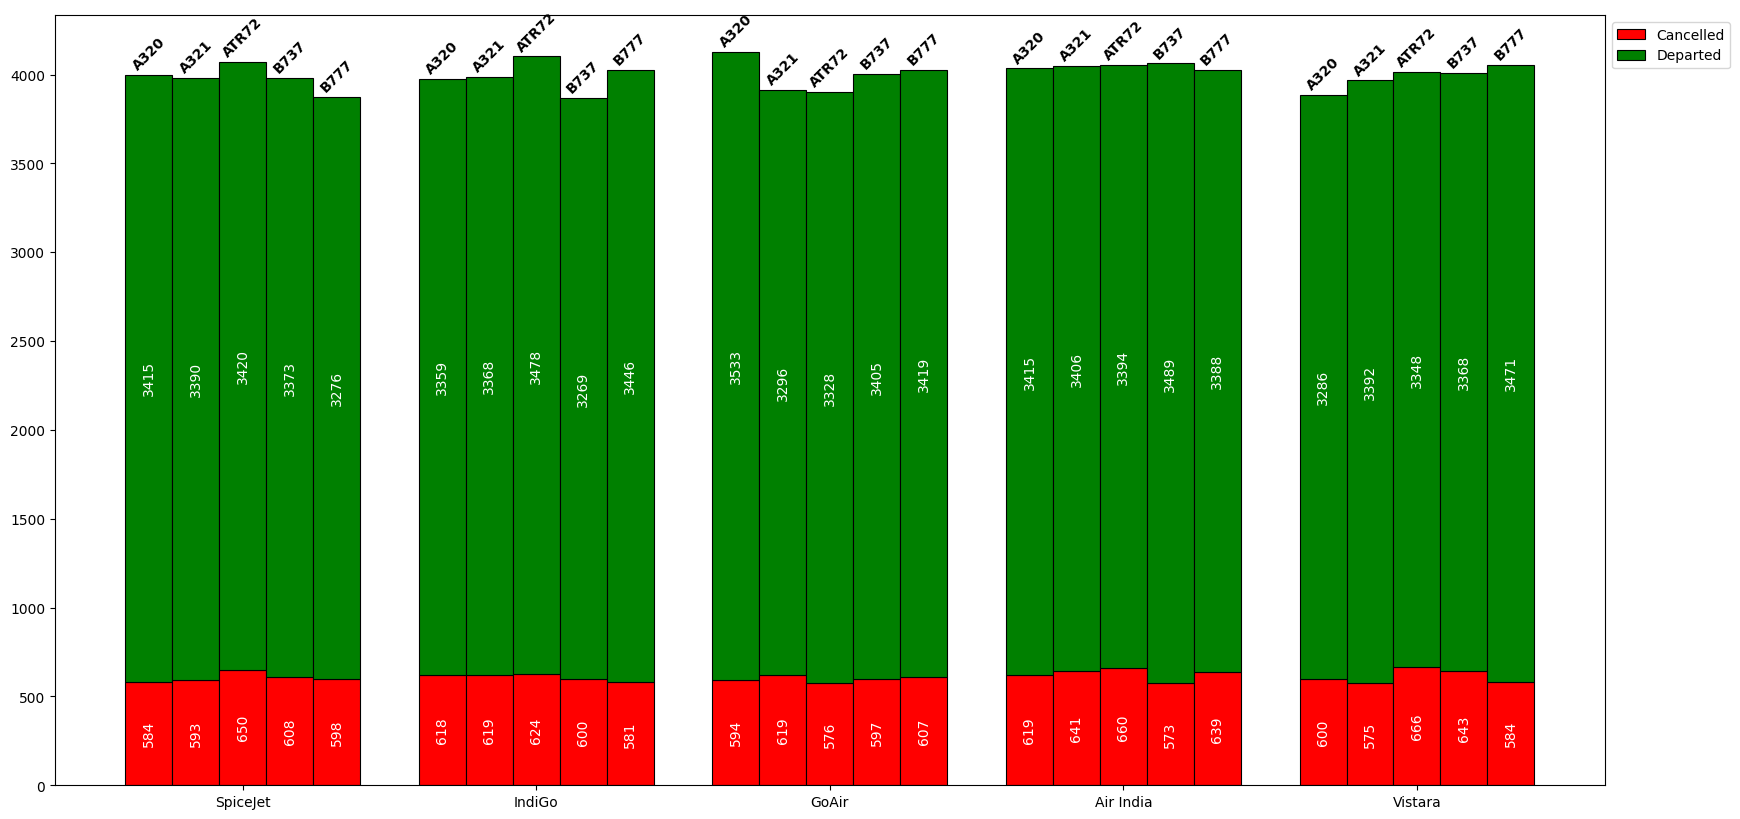

In [110]:
air = Cancelled_airtype.index
aircrafts = Cancelled_airtype.columns

x = np.arange(len(air))
width = 0.8

plt.figure(figsize=(20, 10))

bar_width = width / len(aircrafts)

for i, airline in enumerate(air):
    start = x[i] - width / 2 + bar_width / 2

    for j, aircraft in enumerate(aircrafts):
        bottom = 0
        xpos = start + j * bar_width

        cval = Cancelled_airtype.loc[airline, aircraft]
        dval = Departed_airtype.loc[airline, aircraft]

        b1 = plt.bar(
            xpos, cval,
            width=bar_width,
            bottom=bottom,
            color="red",
            label="Cancelled" if (i == 0 and j == 0) else None,
            edgecolor="black",
            linewidth=0.8
        )
        plt.bar_label(b1, label_type="center", color="white", rotation=90)

        bottom += cval

        b2 = plt.bar(
            xpos, dval,
            width=bar_width,
            bottom=bottom,
            color="green",
            label="Departed" if (i == 0 and j == 0) else None,
            edgecolor="black",
            linewidth=0.8
        )
        plt.bar_label(b2, label_type="center", color="white", rotation=90)

        bottom += dval

        plt.text(
            xpos, bottom + 30,
            aircraft,
            ha="center",
            rotation=45,
            fontweight="bold"
        )

plt.xticks(x, air)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()


In [111]:
def time(a):
    t=a.split(",")[1].split(":")
    tm=round((int(t[0])*3600+int(t[1])*60+int(t[2]))/86400,2)
    return int(a.split(",")[0].split()[0])+tm

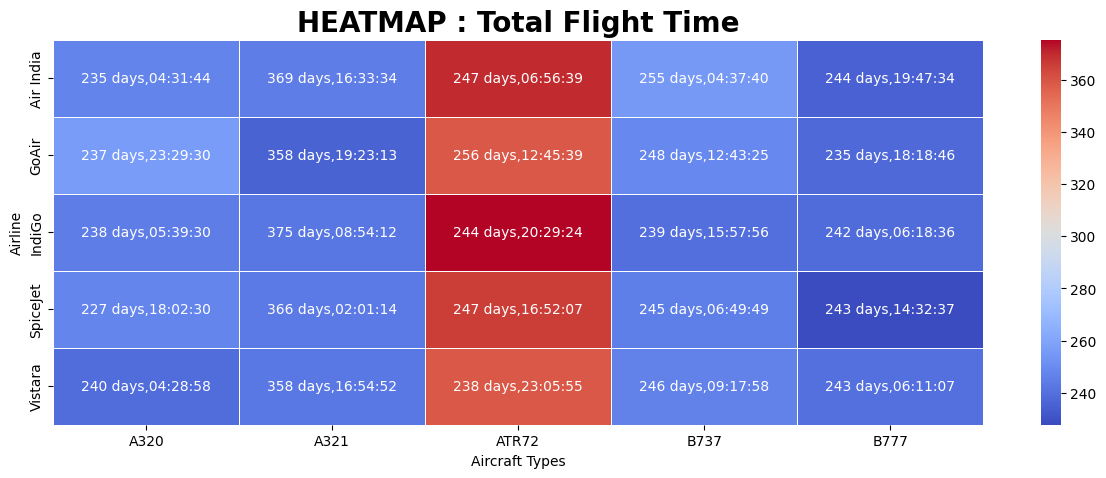

In [112]:
Total_flight_times=Total_flight_time.unstack().reset_index()
Total_flight_times[1]=Total_flight_times[0].apply(time)

plt_df=Total_flight_times.pivot(index="level_1",columns="level_0",values=1)
plt.figure(figsize=(15,5))
sns.heatmap(plt_df,annot=Total_flight_time,fmt="",cmap="coolwarm",linewidths=0.5,linecolor="white")
plt.xlabel("Aircraft Types")
plt.ylabel("Airline")
plt.title("HEATMAP : Total Flight Time",fontsize=20,fontweight="bold")
plt.show()

In [113]:
Total_flight_time

,B777,ATR72,A320,B737,A321
Air India,"235 days,04:31:44","369 days,16:33:34","247 days,06:56:39","255 days,04:37:40","244 days,19:47:34"
GoAir,"237 days,23:29:30","358 days,19:23:13","256 days,12:45:39","248 days,12:43:25","235 days,18:18:46"
IndiGo,"238 days,05:39:30","375 days,08:54:12","244 days,20:29:24","239 days,15:57:56","242 days,06:18:36"
SpiceJet,"227 days,18:02:30","366 days,02:01:14","247 days,16:52:07","245 days,06:49:49","243 days,14:32:37"
Vistara,"240 days,04:28:58","358 days,16:54:52","238 days,23:05:55","246 days,09:17:58","243 days,06:11:07"


In [114]:
a="235 days,06:49:31"
a.split(",")[1].split(":")

['06', '49', '31']

In [115]:
Aircraft_Delay_flight_count

NameError: name 'Aircraft_Delay_flight_count' is not defined

In [ ]:
origin_aircraft_count

,Airline,Aircraft_Type,Origin,Origin_Flight_Count
0,Air India,A320,AMD,531
1,Air India,A320,BLR,530
2,Air India,A320,BOM,473
3,Air India,A320,CCU,488
4,Air India,A320,DEL,512
...,...,...,...,...
195,Vistara,B777,CCU,494
196,Vistara,B777,DEL,487
197,Vistara,B777,HYD,497
198,Vistara,B777,MAA,549


In [ ]:
dest_aircraft_count

,Airline,Aircraft_Type,Destination,Destination_Flight_Count
0,Air India,A320,AMD,535
1,Air India,A320,BLR,500
2,Air India,A320,BOM,487
3,Air India,A320,CCU,524
4,Air India,A320,DEL,482
...,...,...,...,...
195,Vistara,B777,CCU,495
196,Vistara,B777,DEL,491
197,Vistara,B777,HYD,485
198,Vistara,B777,MAA,513


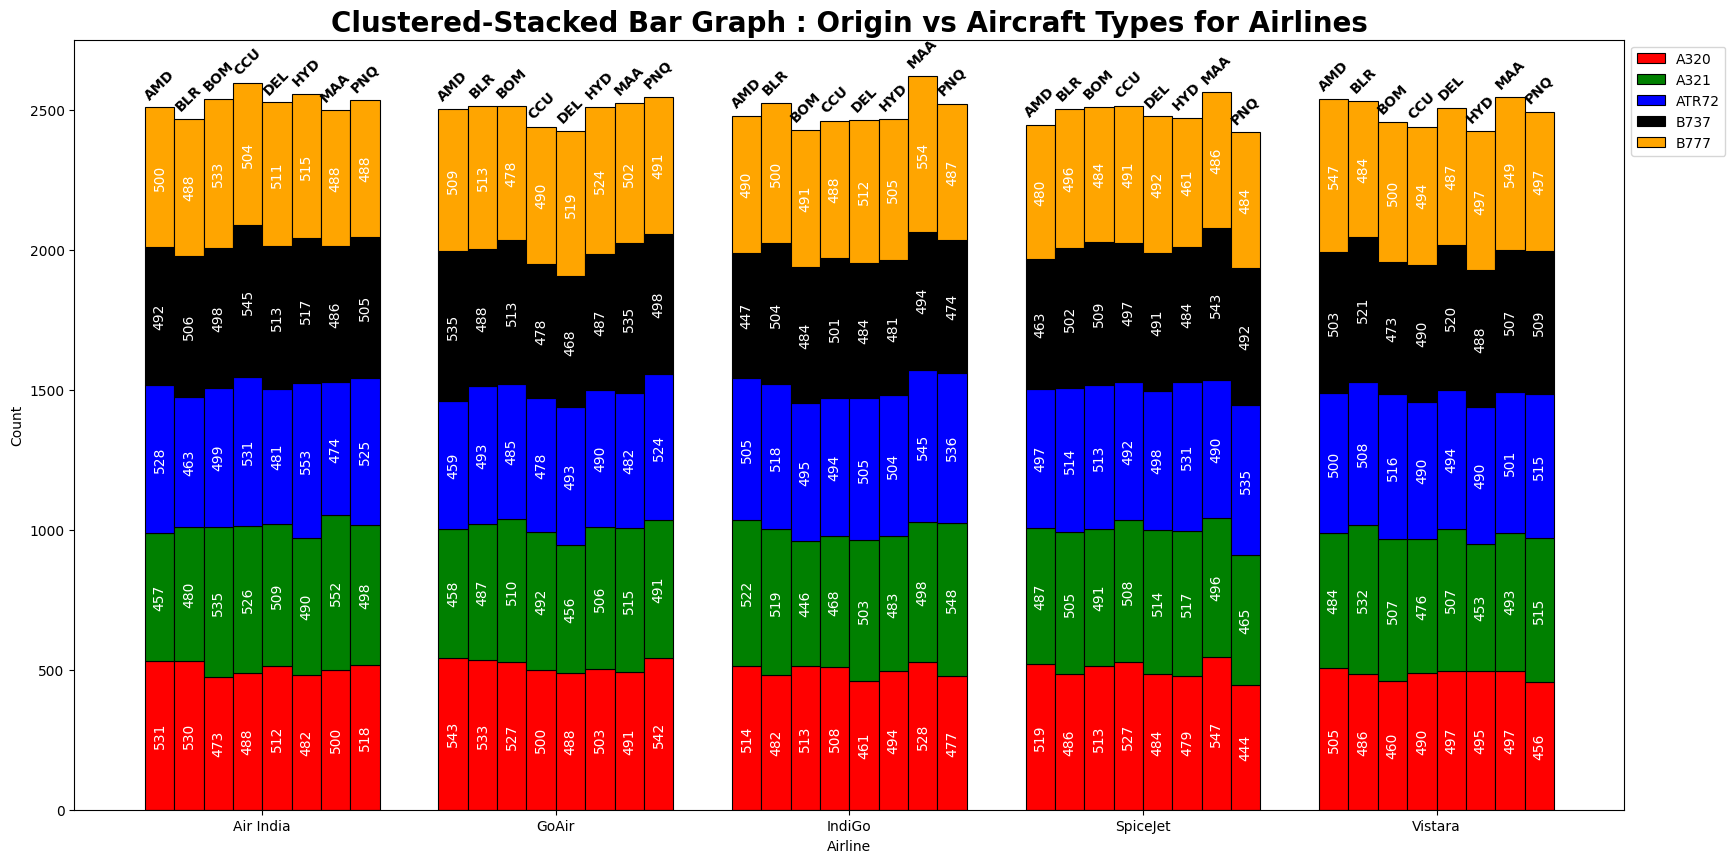

In [ ]:
air=origin_aircraft_count["Airline"].unique()
aircrafts=origin_aircraft_count["Aircraft_Type"].unique()
origins=origin_aircraft_count["Origin"].unique()
x=np.arange(len(air))
width=0.8
bar_width=width/len(origins)
color=["red", "green", "blue", "black", "orange"]
fig,ax=plt.subplots(figsize=(20,10))

for i,airline in enumerate(air):
    sub=origin_aircraft_count[origin_aircraft_count["Airline"]==airline].drop("Airline",axis=1).pivot(index="Origin",
                                                                                                    columns="Aircraft_Type",
                                                                                                    values="Origin_Flight_Count")
    
    start=x[i]-width/2+bar_width/2
    for j,origin in enumerate(origins):
        xpo=start+j*bar_width
        bottom=0
        for k,aircraft in enumerate(aircrafts):
            val=sub.loc[origin,aircraft]
            b1=ax.bar(xpo,val,bar_width,bottom=bottom,color=color[k],label=aircraft if (i==0 and j==0) else None,linewidth=0.8,edgecolor="black")
            ax.bar_label(b1,label_type="center",color="white",rotation=90)
            bottom+=val
        
        ax.text(xpo,bottom+30,origin,ha="center",rotation=45,fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(air)
plt.xlabel("Airline")
plt.ylabel("Count")
plt.title("Clustered-Stacked Bar Graph : Origin vs Aircraft Types for Airlines",fontsize=20,fontweight="bold")
plt.legend(bbox_to_anchor=(1,1))
plt.show()


In [ ]:
dest_aircraft_count

,Airline,Aircraft_Type,Destination,Destination_Flight_Count
0,Air India,A320,AMD,535
1,Air India,A320,BLR,500
2,Air India,A320,BOM,487
3,Air India,A320,CCU,524
4,Air India,A320,DEL,482
...,...,...,...,...
195,Vistara,B777,CCU,495
196,Vistara,B777,DEL,491
197,Vistara,B777,HYD,485
198,Vistara,B777,MAA,513


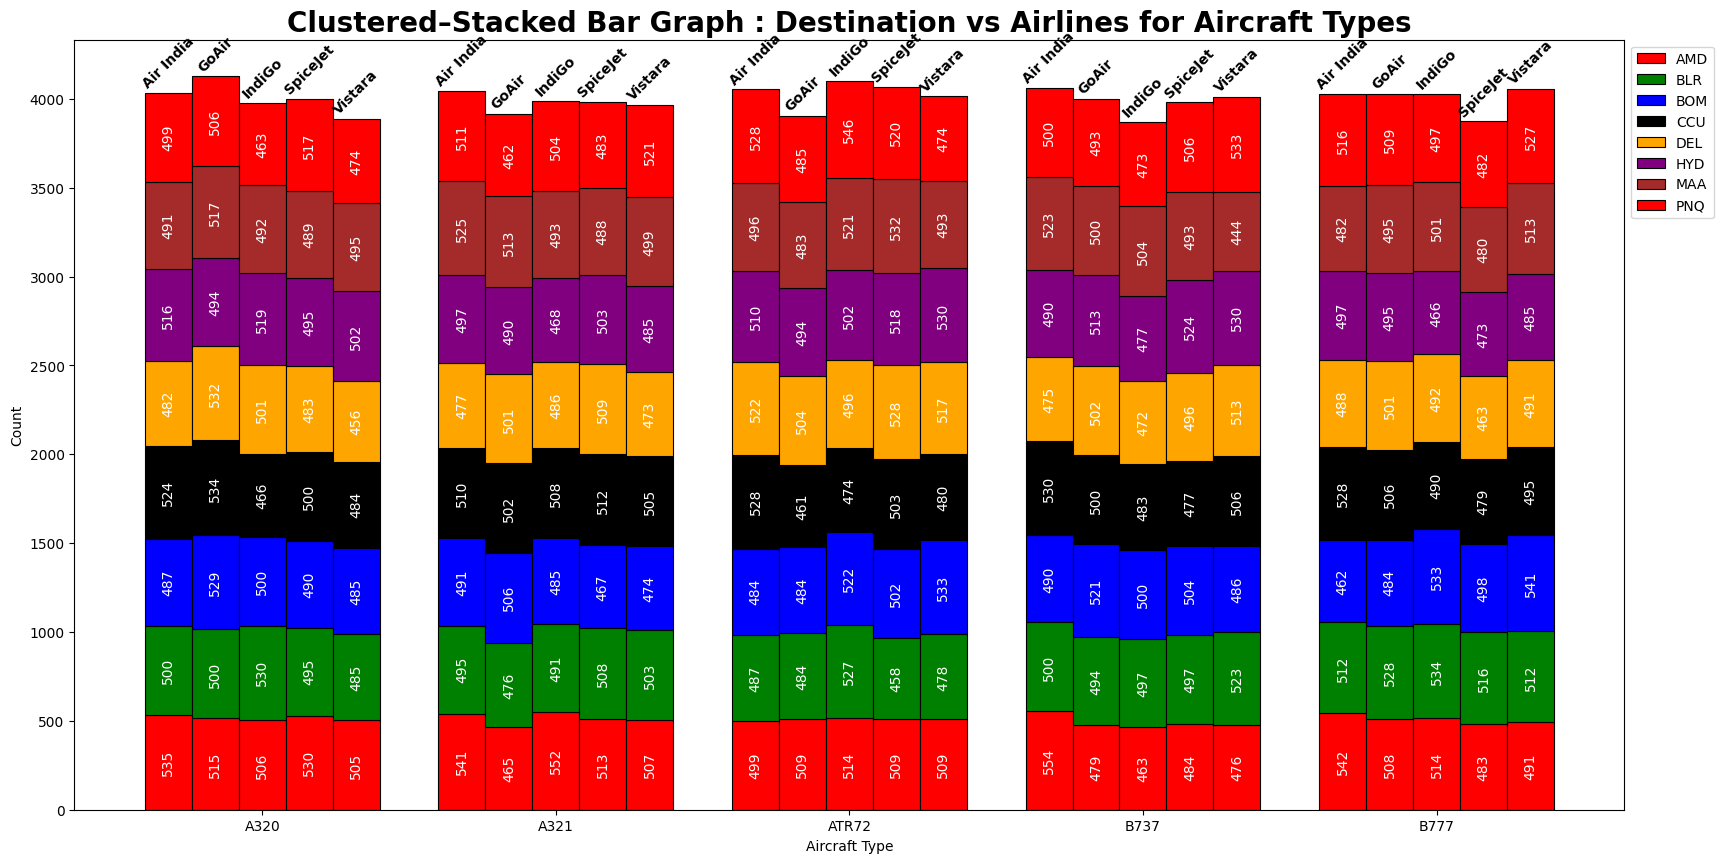

In [ ]:
airlines = dest_aircraft_count["Airline"].unique()
aircrafts = dest_aircraft_count["Aircraft_Type"].unique()
destinations = dest_aircraft_count["Destination"].unique()

x = np.arange(len(aircrafts))
width = 0.8
bar_width = width / len(airlines)

color = ["red", "green", "blue", "black", "orange", "purple", "brown"]

fig, ax = plt.subplots(figsize=(20, 10))

for i, aircraft in enumerate(aircrafts):
    sub = dest_aircraft_count[
        dest_aircraft_count["Aircraft_Type"] == aircraft
    ].drop("Aircraft_Type", axis=1).pivot(
        index="Airline",
        columns="Destination",
        values="Destination_Flight_Count"
    )

    start = x[i] - width / 2 + bar_width / 2

    for j, airline in enumerate(airlines):
        xpo = start + j * bar_width
        bottom = 0

        for k, dest in enumerate(destinations):
            val = sub.loc[airline, dest]

            b1 = ax.bar(
                xpo,
                val,
                bar_width,
                bottom=bottom,
                color=color[k % len(color)],
                label=dest if (i == 0 and j == 0) else None,
                linewidth=0.8,
                edgecolor="black"
            )

            ax.bar_label(b1, label_type="center", color="white", rotation=90)
            bottom += val

        ax.text(
            xpo,
            bottom + 30,
            airline,
            ha="center",
            rotation=45,
            fontweight="bold"
        )

ax.set_xticks(x)
ax.set_xticklabels(aircrafts)
plt.xlabel("Aircraft Type")
plt.ylabel("Count")
plt.title("Clustered–Stacked Bar Graph : Destination vs Airlines for Aircraft Types", fontsize=20, fontweight="bold")

plt.legend(bbox_to_anchor=(1, 1))
plt.show()


In [ ]:
airtype_profit

,A321,ATR72,B777,B737,A320
SpiceJet,-2612315.36,-625218.36,-4226414.86,-3627735.96,-3445010.84
IndiGo,-1354005.01,322056.46,-2986265.99,-2559435.65,-2381746.50
GoAir,-3652733.03,-1818354.08,-5773677.34,-4785728.47,-4670295.29
Air India,-69676.18,1270534.08,-1849152.72,-1593193.97,-1186045.95
Vistara,2494977.97,3600719.98,761082.83,585294.39,810371.34


In [ ]:
airtype_profit

,A321,ATR72,B777,B737,A320
SpiceJet,-2612315.36,-625218.36,-4226414.86,-3627735.96,-3445010.84
IndiGo,-1354005.01,322056.46,-2986265.99,-2559435.65,-2381746.50
GoAir,-3652733.03,-1818354.08,-5773677.34,-4785728.47,-4670295.29
Air India,-69676.18,1270534.08,-1849152.72,-1593193.97,-1186045.95
Vistara,2494977.97,3600719.98,761082.83,585294.39,810371.34


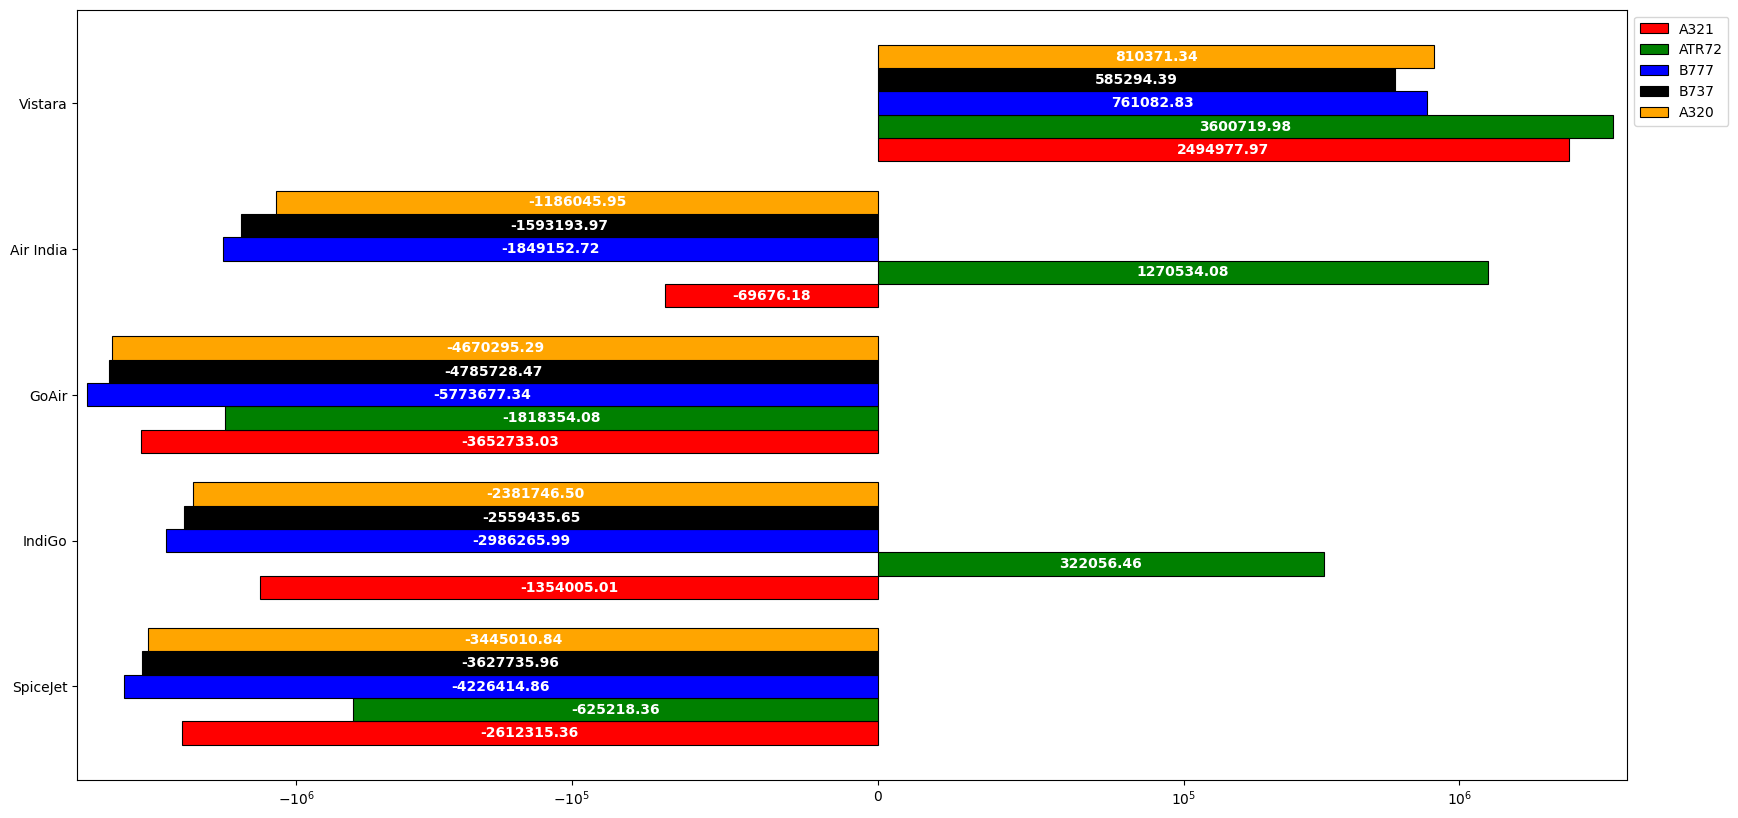

In [ ]:
plt.figure(figsize=(20, 10))
air = airtype_profit.index
aircrafts = airtype_profit.columns
y = np.arange(len(air))
height = 0.8
bar_height = height / len(aircrafts)
color = ["red", "green", "blue", "black", "orange"]

for i, airline in enumerate(air):
    start = y[i] - height / 2 + bar_height / 2
    for j, aircraft in enumerate(aircrafts):
        ypo = start + j * bar_height
        val = airtype_profit.loc[airline, aircraft]
        b1 = plt.barh(ypo, val, bar_height, color=color[j], label=aircraft if i == 0 else None, linewidth=0.8, edgecolor="black")
        plt.bar_label(b1, fmt="%.2f", label_type="center", color="white", fontweight="bold")

plt.xscale("symlog", linthresh=1e5)
plt.yticks(y, air)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

Delay_Range,Airline,Aircraft_Type,"(00:00:00, 00:09:59)","(00:10:00, 00:19:59)","(00:20:00, 00:29:59)","(00:30:00, 00:39:59)","(00:40:00, 00:49:59)","(00:50:00, 00:59:59)","(01:00:00, 01:09:59)","(01:10:00, 01:19:59)",...,"(98:20:00, 98:29:59)","(98:30:00, 98:39:59)","(98:40:00, 98:49:59)","(98:50:00, 98:59:59)","(99:00:00, 99:09:59)","(99:10:00, 99:19:59)","(99:20:00, 99:29:59)","(99:30:00, 99:39:59)","(99:40:00, 99:49:59)","(99:50:00, 99:59:59)"
0,Air India,A320,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Air India,A321,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Air India,ATR72,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Air India,B737,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Air India,B777,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,GoAir,A320,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,GoAir,A321,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,GoAir,ATR72,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,GoAir,B737,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,GoAir,B777,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
ADCD = {i: 
    {k: 
        {(r, stp_dm(r)): 
            df[(df["Airline"] == i) & 
               (df["Aircraft_Type"] == k) & 
               (df["Distance_km"] != 0.0) & 
               (df["Delay_minutes"] >= r) & 
               (df["Delay_minutes"] <= stp_dm(r))]["Flight_Number"].count() for r in rng_dm(max(df[(df["Airline"] == i) & 
                                                                                               (df["Aircraft_Type"] == k) & 
                                                                                               (df["Distance_km"] != 0.0)]["Delay_minutes"].unique().tolist()))
        } for k in j
    } for i, j in df.groupby("Airline")["Aircraft_Type"].unique().to_dict().items()
}

rows = []
for airline, j in ADCD.items():
    for aircraft, k in j.items():
        for rng, count in k.items():
            rows.append({
                "Airline": airline,
                "Aircraft_Type": aircraft,
                "Delay_Range": rng,
                "Flight_Count": count
            })

Aircraft_Delay_flight_count = pd.DataFrame(rows).pivot_table(index=["Airline", "Aircraft_Type"],
                                                           columns="Delay_Range",
                                                           values="Flight_Count",
                                                           fill_value=0).astype("int").reset_index()

In [117]:
Aircraft_Delay_flight_count

Delay_Range,Airline,Aircraft_Type,0–9 min,1000–1009 min,100–109 min,1010–1019 min,1020–1029 min,1030–1039 min,1040–1049 min,1050–1059 min,...,90–99 min,910–919 min,920–929 min,930–939 min,940–949 min,950–959 min,960–969 min,970–979 min,980–989 min,990–999 min
0,Air India,A320,10,16,14,14,9,11,12,9,...,6,11,10,9,11,11,5,14,14,17
1,Air India,A321,7,10,12,13,17,9,19,11,...,12,12,9,20,20,11,13,15,17,15
2,Air India,ATR72,10,16,7,15,8,10,14,11,...,18,13,14,19,22,10,15,11,16,10
3,Air India,B737,6,22,17,12,11,8,19,13,...,7,12,15,21,18,12,17,16,17,16
4,Air India,B777,11,12,10,16,13,18,13,6,...,10,15,17,17,17,23,13,15,9,12
5,GoAir,A320,9,9,17,13,14,11,17,14,...,8,11,13,12,10,14,20,11,12,12
6,GoAir,A321,9,10,9,10,12,15,11,8,...,9,10,10,9,20,18,15,14,7,17
7,GoAir,ATR72,8,9,4,7,12,10,14,14,...,7,15,14,15,11,23,12,6,8,13
8,GoAir,B737,9,9,12,15,13,12,15,8,...,5,11,14,10,10,8,13,10,13,7
9,GoAir,B777,5,9,12,20,10,14,8,8,...,11,12,19,8,11,6,19,18,7,10


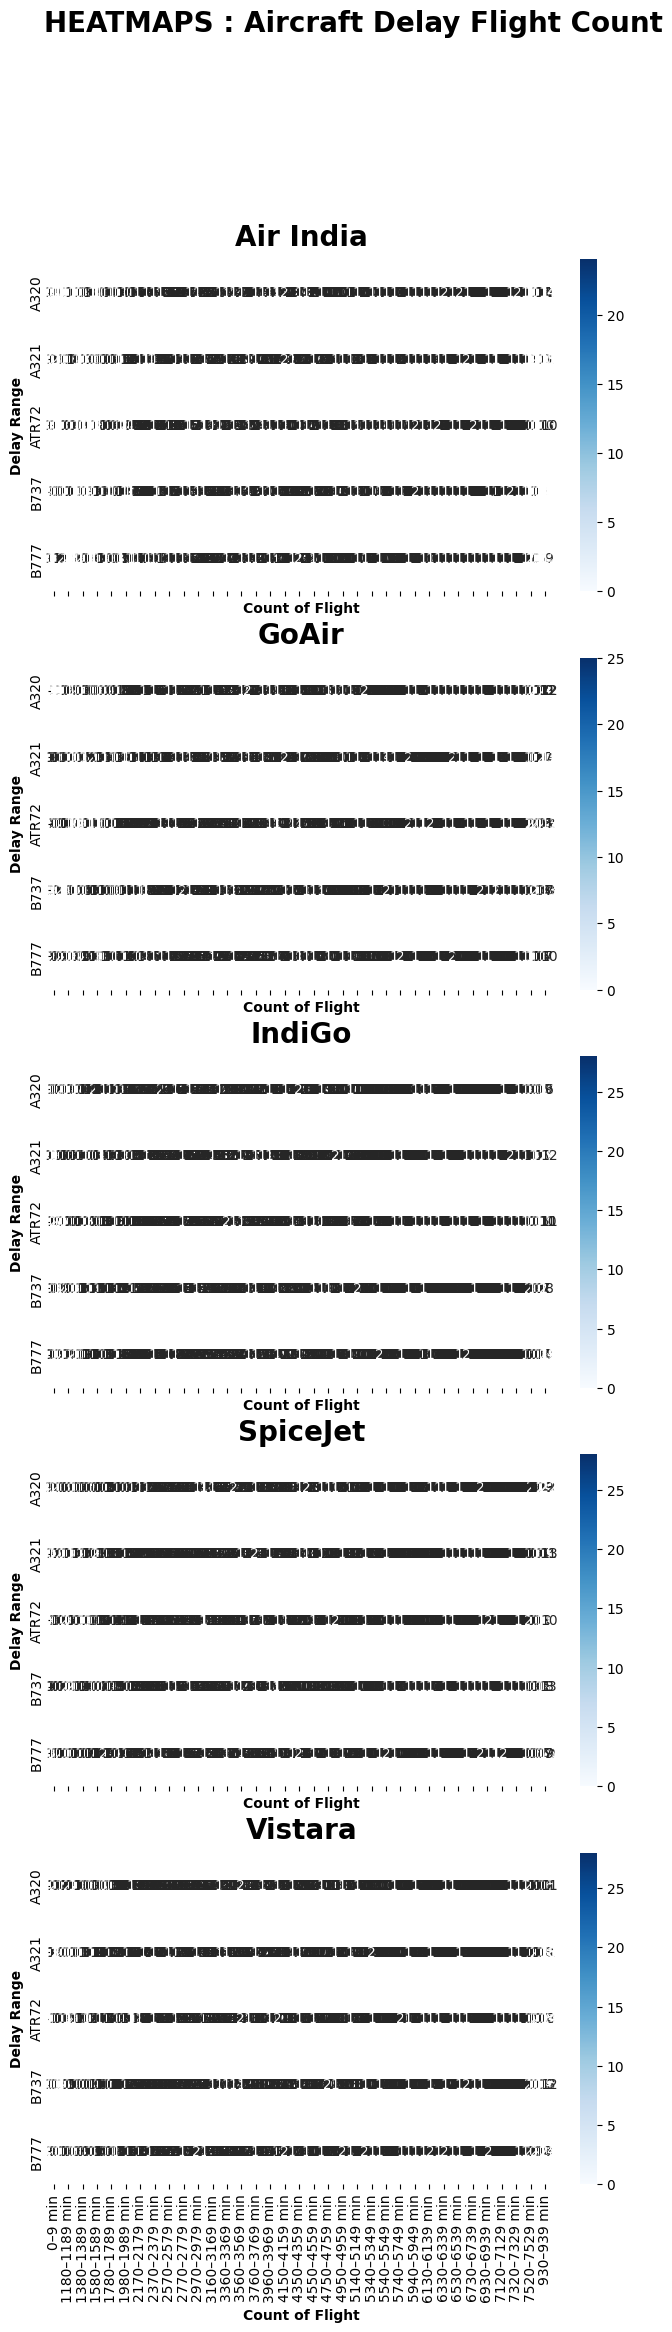

In [118]:
air = Aircraft_Delay_flight_count["Airline"].unique()
fig, axes = plt.subplots(len(air), 1, figsize=(8, 25), sharex=True)

for i, airline in enumerate(air):
    ax = axes[i]
    sub = Aircraft_Delay_flight_count[Aircraft_Delay_flight_count["Airline"] == airline].drop("Airline", axis=1).set_index("Aircraft_Type")
    sns.heatmap(sub, annot=True, fmt="d", ax=ax, cmap="Blues", linewidths=0.5)
    ax.set_title(airline, fontsize=20, fontweight="bold", pad=10)
    ax.set_ylabel("Delay Range", fontsize=10, fontweight="bold")
    ax.set_xlabel("Count of Flight", fontsize=10, fontweight="bold")

plt.suptitle("HEATMAPS : Aircraft Delay Flight Count", fontsize=20, fontweight="bold")
plt.show()

In [ ]:
Daily_flight_count

Days,month,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,January,232,215,240,221,243,231,251,212,229,...,246,212,223,244,214,213,217,206,225,244
1,February,229,201,241,230,254,258,200,240,249,...,231,238,229,213,233,227,259,0,0,0
2,March,230,202,234,248,240,240,261,226,253,...,210,249,259,217,245,249,231,230,220,250
3,April,222,213,206,240,233,237,234,233,249,...,259,217,208,247,220,247,240,226,228,0
4,May,241,231,246,219,241,225,234,227,214,...,231,227,244,212,221,204,225,233,242,205
5,June,220,250,238,237,267,223,253,238,252,...,202,231,240,236,242,243,275,230,211,0
6,July,221,222,223,252,264,241,228,239,227,...,243,258,224,228,233,244,208,221,240,219
7,August,224,233,252,246,221,235,221,223,240,...,252,224,205,243,210,229,233,209,225,229
8,September,227,227,238,226,242,245,250,259,234,...,292,239,211,242,231,251,220,252,215,0
9,October,250,256,226,239,259,236,228,227,213,...,237,228,232,218,208,212,216,258,214,232


In [ ]:
df["Delay_minutes"].describe()


count      100000
unique       5623
top       000:000
freq        17410
Name: Delay_minutes, dtype: object

In [ ]:
def delay_to_minutes(x):
    if pd.isna(x):
        return 0
    h, m = x.split(":")
    return int(h) * 60 + int(m)


In [ ]:
import pandas as pd
import numpy as np

# -------------------------------
# 1. Convert Delay from HH:MM string → total minutes
# -------------------------------
def delay_to_minutes(x):
    if pd.isna(x):
        return 0
    try:
        h, m = x.split(":")
        return int(h) * 60 + int(m)
    except:
        return 0

df["Delay_minutes_num"] = df["Delay_minutes"].apply(delay_to_minutes)

# -------------------------------
# 2. Delay range helpers
# -------------------------------
def stp_dm(x, step=10):
    return x + step - 1

def rng_dm(max_delay, step=10):
    return range(0, max_delay + step, step)

# -------------------------------
# 3. Build Airline → Aircraft → DelayRange → Count
# -------------------------------
ADCD = {
    airline: {
        aircraft: {
            (r, stp_dm(r)): df[
                (df["Airline"] == airline) &
                (df["Aircraft_Type"] == aircraft) &
                (df["Delay_minutes_num"] > 0) &         # ignore zero-delay flights
                (df["Delay_minutes_num"] >= r) &
                (df["Delay_minutes_num"] <= stp_dm(r))
            ]["Flight_Number"].count()
            for r in rng_dm(
                df[
                    (df["Airline"] == airline) &
                    (df["Aircraft_Type"] == aircraft)
                ]["Delay_minutes_num"].max()
            )
        }
        for aircraft in aircrafts
    }
    for airline, aircrafts in df.groupby("Airline")["Aircraft_Type"].unique().to_dict().items()
}

# -------------------------------
# 4. Convert nested dict → DataFrame
# -------------------------------
rows = []
for airline, aircraft_dict in ADCD.items():
    for aircraft, delay_dict in aircraft_dict.items():
        for delay_range, count in delay_dict.items():
            rows.append({
                "Airline": airline,
                "Aircraft_Type": aircraft,
                "Delay_Range": f"{delay_range[0]}–{delay_range[1]} min",
                "Flight_Count": count
            })

Aircraft_Delay_flight_count = (
    pd.DataFrame(rows)
    .pivot_table(
        index=["Airline", "Aircraft_Type"],
        columns="Delay_Range",
        values="Flight_Count",
        fill_value=0
    )
    .astype(int)
    .reset_index()
)




Delay_Range    Airline Aircraft_Type  0–9 min  1000–1009 min  100–109 min  \
0            Air India          A320       10             16           14   
1            Air India          A321        7             10           12   
2            Air India         ATR72       10             16            7   
3            Air India          B737        6             22           17   
4            Air India          B777       11             12           10   

Delay_Range  1010–1019 min  1020–1029 min  1030–1039 min  1040–1049 min  \
0                       14              9             11             12   
1                       13             17              9             19   
2                       15              8             10             14   
3                       12             11              8             19   
4                       16             13             18             13   

Delay_Range  1050–1059 min  ...  90–99 min  910–919 min  920–929 min  \
0             

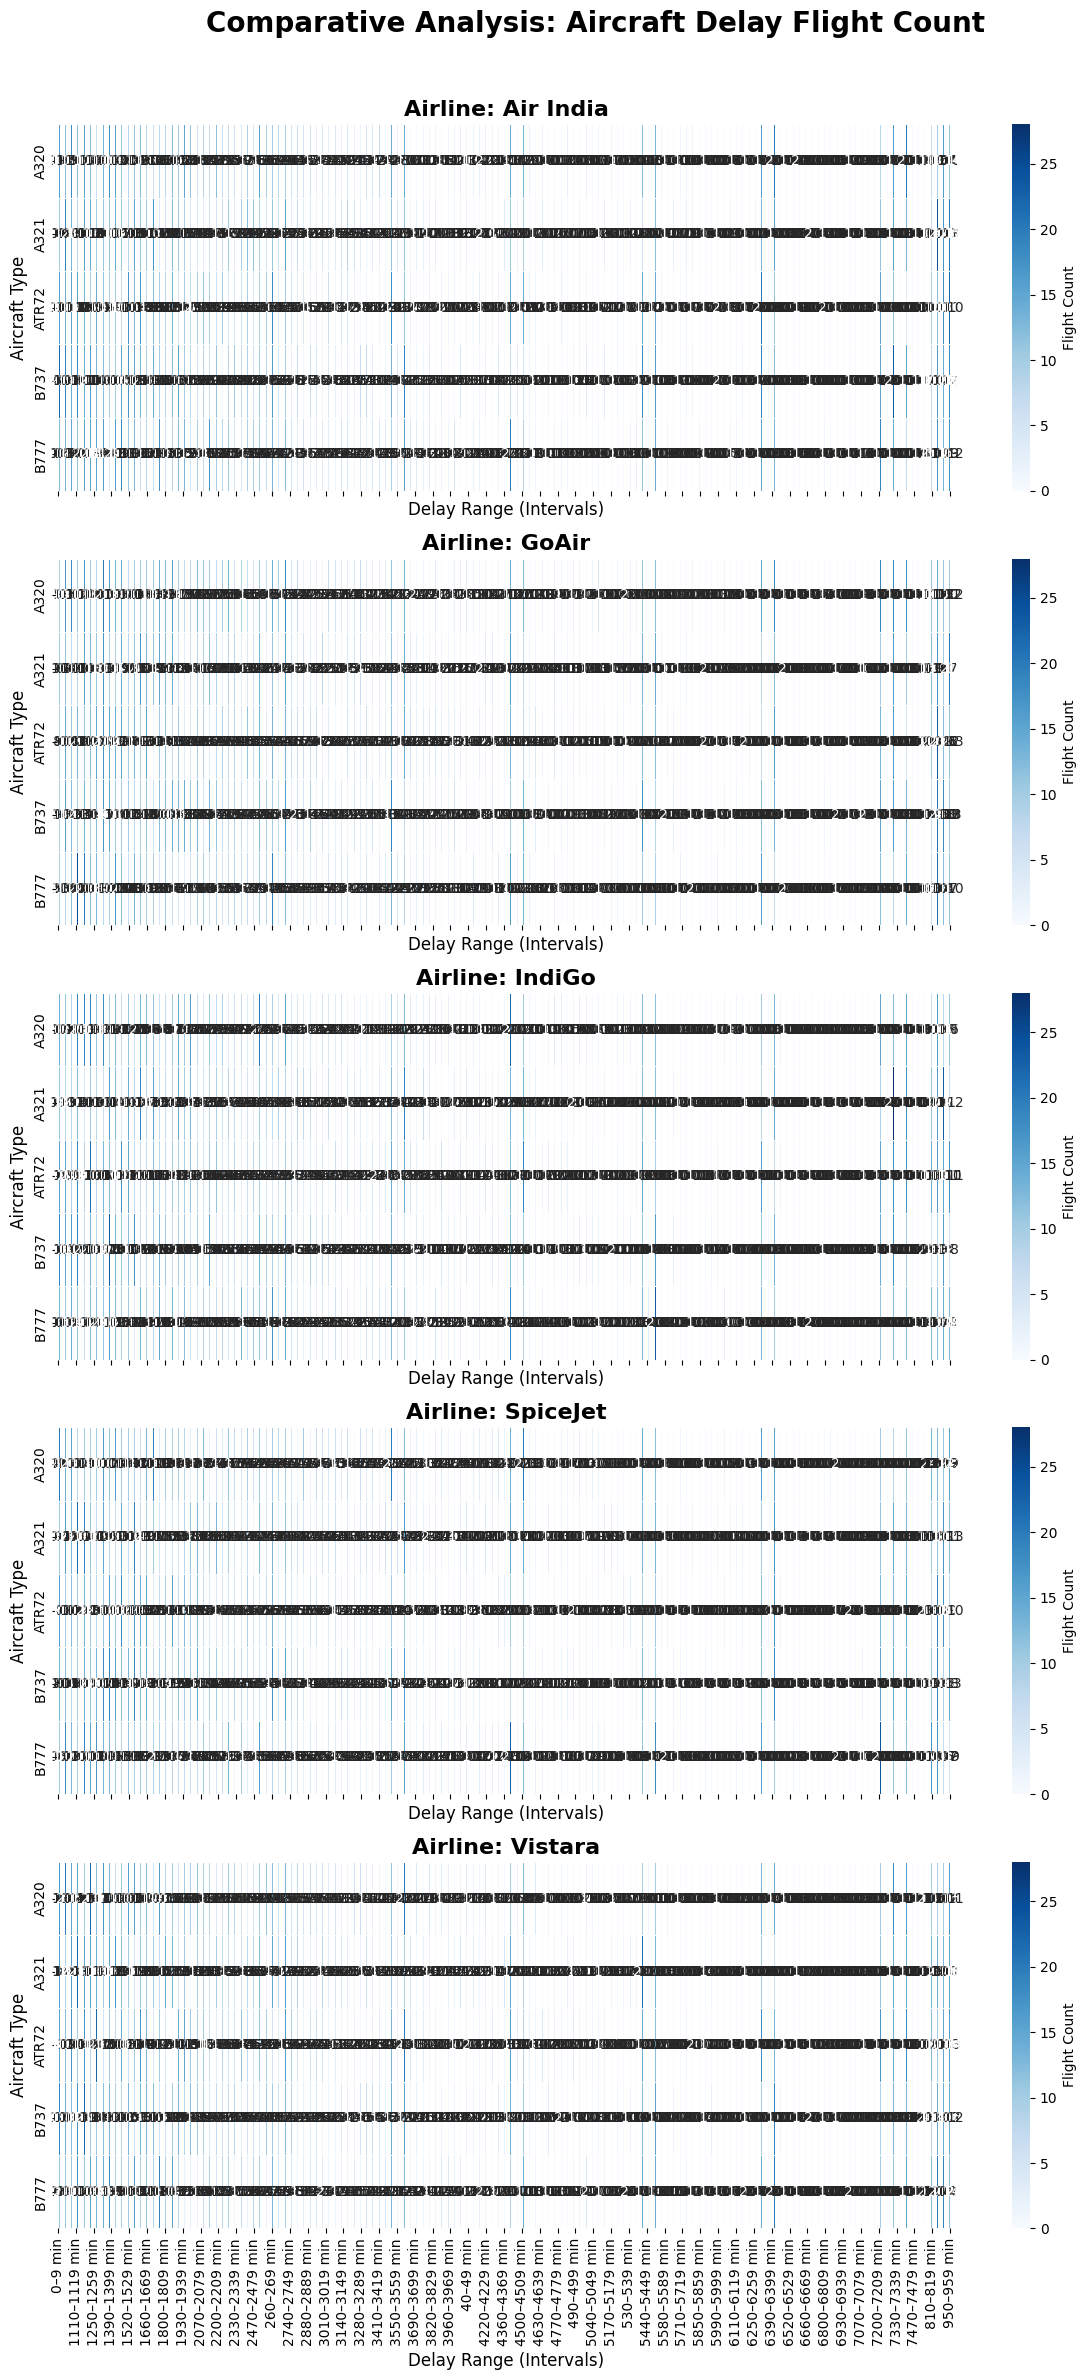

In [121]:
air = Aircraft_Delay_flight_count["Airline"].unique()
# Adjust height based on number of airlines to prevent squashing
fig, axes = plt.subplots(len(air), 1, figsize=(12, 5 * len(air)), sharex=True)

# Find global max to keep color scale consistent
vmax = Aircraft_Delay_flight_count.iloc[:, 2:].max().max()

for i, airline in enumerate(air):
    ax = axes[i]
    # Filter and prep data
    sub = Aircraft_Delay_flight_count[Aircraft_Delay_flight_count["Airline"] == airline].drop("Airline", axis=1).set_index("Aircraft_Type")
    
    # Plot with consistent scale and better formatting
    sns.heatmap(sub, annot=True, fmt="d", ax=ax, cmap="Blues", 
                linewidths=0.5, vmin=0, vmax=vmax, cbar_kws={'label': 'Flight Count'})
    
    ax.set_title(f"Airline: {airline}", fontsize=16, fontweight="bold")
    ax.set_ylabel("Aircraft Type", fontsize=12) # Changed from 'Delay Range'
    ax.set_xlabel("Delay Range (Intervals)", fontsize=12) # Changed from 'Count of Flight'

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.suptitle("Comparative Analysis: Aircraft Delay Flight Count", fontsize=20, fontweight="bold")
plt.show()